In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install matplotlib-venn # Install the library for Venn diagrams if not already installed
from matplotlib_venn import venn2

# 1. Mount Google Drive to access your files
from google.colab import drive
drive.mount('/content/drive')

# --- Next Steps ---
# Please provide the paths to your Excel files and their sheet names below.
# If your column names for log2FoldChange and padj are different, please update them.

file1_path = '/content/drive/MyDrive/mrsa/rnaseq/DEresults_6hrhr.xlsx' # through github: '../data/DEG_RNA/DEresults_6hrhr.xlsx' 
file1_sheet_name = 'res_MRSA' # REPLACE WITH YOUR SHEET NAME

file2_path = '/content/drive/MyDrive/mrsa/rnaseq/DEresults_24hrhr.xlsx' # through github: '../data/DEG_RNA/DEresults_24hrhr.xlsx' 
file2_sheet_name = 'res_MRSA' # REPLACE WITH YOUR SHEET NAME

log2_fold_change_col = 'log2FoldChange' # REPLACE IF DIFFERENT
p_adj_col = 'padj' # REPLACE IF DIFFERENT

# Example filtering criteria (you can adjust these values):
log2_threshold = 1
padj_threshold = 0.05

# Once you provide the file paths and column names, I can help you with the filtering and Venn diagram generation.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Load the dataframes
try:
    df1 = pd.read_excel(file1_path, sheet_name=file1_sheet_name)
    df2 = pd.read_excel(file2_path, sheet_name=file2_sheet_name)
    print(f"Successfully loaded {file1_path} from sheet '{file1_sheet_name}'.")
    print(f"Successfully loaded {file2_path} from sheet '{file2_sheet_name}'.")
except FileNotFoundError as e:
    print(f"Error: One of the files was not found. Please check the paths. {e}")
    print("File 1 Path:", file1_path)
    print("File 2 Path:", file2_path)
except Exception as e:
    print(f"An error occurred while loading the Excel files: {e}")

# Display the first few rows and columns of each dataframe to verify loading
if 'df1' in locals() and 'df2' in locals():
    print("\nFirst 5 rows of DataFrame 1 (6hrhr):")
    print(df1.head())
    print("\nColumns in DataFrame 1:", df1.columns.tolist())

    print("\nFirst 5 rows of DataFrame 2 (24hrhr):")
    print(df2.head())
    print("\nColumns in DataFrame 2:", df2.columns.tolist())


Successfully loaded /content/drive/MyDrive/mrsa/rnaseq/DEresults_6hrhr.xlsx from sheet 'res_MRSA'.
Successfully loaded /content/drive/MyDrive/mrsa/rnaseq/DEresults_24hrhr.xlsx from sheet 'res_MRSA'.

First 5 rows of DataFrame 1 (6hrhr):
      baseMean  log2FoldChange     lfcSE      stat        pvalue  \
0   247.646257       -1.693508  0.242674 -6.978544  2.982550e-12   
1  1748.575640        0.651407  0.157497  4.135992  3.534240e-05   
2   469.906344        0.038041  0.175856  0.216316  8.287412e-01   
3   167.808643       -0.387734  0.259483 -1.494254  1.351093e-01   
4  1981.268912        0.276959  0.138966  1.993006  4.626081e-02   

           padj          ensembl   entrez hgnc_symbol  
0  3.627907e-11  ENSG00000000003   7105.0      TSPAN6  
1  1.861809e-04  ENSG00000000419   8813.0        DPM1  
2  9.024614e-01  ENSG00000000457  57147.0       SCYL3  
3  2.622461e-01  ENSG00000000460  55732.0    C1orf112  
4  1.097715e-01  ENSG00000000938   2268.0         FGR  

Columns in DataFr

In [ ]:
# 3. Filter for Differentially Expressed Genes (DEGs)

# Ensure the required columns exist in both dataframes
required_cols = [log2_fold_change_col, p_adj_col]

for df_name, df in zip(['df1', 'df2'], [df1, df2]):
    if not all(col in df.columns for col in required_cols):
        print(f"Error: Missing one or more required columns ({required_cols}) in {df_name}.")
        print(f"Available columns in {df_name}: {df.columns.tolist()}")
        # You might want to stop execution or handle this error differently

# Filter for DEGs in df1
degs1 = df1[
    (df1[log2_fold_change_col].abs() >= log2_threshold) &
    (df1[p_adj_col] <= padj_threshold)
].copy()
degs1_genes = set(degs1.hgnc_symbol)

# Filter for DEGs in df2
degs2 = df2[
    (df2[log2_fold_change_col].abs() >= log2_threshold) &
    (df2[p_adj_col] <= padj_threshold)
].copy()
degs2_genes = set(degs2.hgnc_symbol)

print(f"\nNumber of DEGs in 6hrhr data: {len(degs1_genes)}")
print(f"Number of DEGs in 24hrhr data: {len(degs2_genes)}")

print("\nFirst 5 DEGs from 6hrhr data:")
print(list(degs1_genes)[:5])

print("\nFirst 5 DEGs from 24hrhr data:")
print(list(degs2_genes)[:5])



Number of DEGs in 6hrhr data: 3650
Number of DEGs in 24hrhr data: 3822

First 5 DEGs from 6hrhr data:
['ACADM', 'CLHC1', 'PPM1L', 'AQP9', 'KCNK15']

First 5 DEGs from 24hrhr data:
['DCAF4', 'AQP9', 'LINC01191', 'GABBR2', 'SGTB']


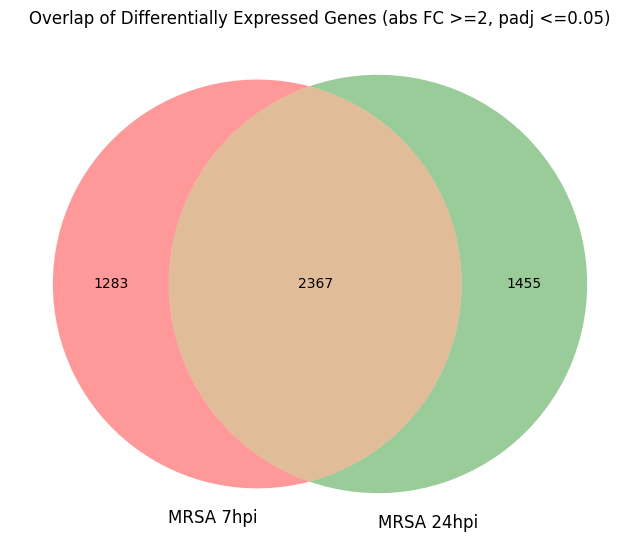


Number of common DEGs: 2367
Common DEGs (first 10 if many):
['AQP9', 'GABBR2', 'SOD2', 'RSPO1', 'B4GALT1', 'PNMA2', 'FST', 'GOLGA6L5P', 'ARHGAP24', 'ENAH']


In [ ]:
# 4. Create Venn Diagram

plt.figure(figsize=(8, 8))
venn2([degs1_genes, degs2_genes], ('MRSA 7hpi', 'MRSA 24hpi'))
plt.title('Overlap of Differentially Expressed Genes (abs FC >=2, padj <=0.05)')
plt.savefig('S5A_rna_mrsa_deg_venn.svg', format='svg') # Save the Venn diagram as an SVG file
plt.show()

# Optional: Print common genes
common_genes = degs1_genes.intersection(degs2_genes)
print(f"\nNumber of common DEGs: {len(common_genes)}")
if len(common_genes) > 0:
    print("Common DEGs (first 10 if many):")
    print(list(common_genes)[:10])
